<a href="https://colab.research.google.com/github/chanita-lab/GE338-Code/blob/main/LAB_4/Lab4_Geographic__modelingl_6606614680_%E0%B8%8A%E0%B8%99%E0%B8%B4%E0%B8%95%E0%B8%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install geemap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.6 MB/s eta 0:00:00


In [17]:
import ee
import geemap
import rasterio
import numpy as np
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='ee-chanita')

In [3]:
# Spatial Suitability Model

import ee
import geemap

# --- ROI ---
admin = ee.FeatureCollection("FAO/GAUL/2015/level1")
roi = admin.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Thailand'),
        ee.Filter.stringContains('ADM1_NAME', 'Suphan')
    )
).geometry()

# --- Data Preparation ---
dem       = ee.Image("USGS/SRTMGL1_003").clip(roi)
slope     = ee.Terrain.slope(dem)
rain      = (ee.ImageCollection("ECMWF/ERA5/MONTHLY")
             .select("total_precipitation")
             .filterDate("2020-01-01", "2020-12-31")
             .mean().clip(roi))
water     = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").clip(roi)
water_mask = water.gt(50)
distance  = water_mask.Not().fastDistanceTransform(30).sqrt().clip(roi)
landcover = (ee.ImageCollection("MODIS/061/MCD12Q1")
             .select("LC_Type1")
             .filterDate("2020-01-01", "2020-12-31")
             .first().clip(roi))

# --- Min-Max Statistics ---
def get_minmax(image, region, scale=500):
    return image.reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=region,
        scale=scale,
        bestEffort=True
    )

rain_stats = get_minmax(rain, roi)
dem_stats  = get_minmax(dem, roi)
slope_stats= get_minmax(slope, roi)
dist_stats = get_minmax(distance, roi)

# Verify statistics retrieved
print("Rain stats:", rain_stats.getInfo())
print("DEM stats:", dem_stats.getInfo())
print("Slope stats:", slope_stats.getInfo())
print("Distance stats:", dist_stats.getInfo())

# --- Normalize (0–1) ---
rain_norm  = rain.unitScale(
    rain_stats.get('total_precipitation_min'),
    rain_stats.get('total_precipitation_max'))

elev_norm  = dem.unitScale(
    dem_stats.get('elevation_min'),
    dem_stats.get('elevation_max')
).multiply(-1).add(1)

slope_norm = slope.unitScale(
    slope_stats.get('slope_min'),
    slope_stats.get('slope_max')
).multiply(-1).add(1)

dist_norm  = distance.unitScale(
    dist_stats.get('distance_min'),
    dist_stats.get('distance_max')
).multiply(-1).add(1)

lc_norm = landcover.expression(
    "(b == 12) ? 1"
    ": (b == 14) ? 0.7"
    ": (b == 10) ? 0.5"
    ": 0.2",
    {"b": landcover}
)

# --- Baseline Weights ---
WEIGHTS = {
    'rain':  0.20,
    'elev':  0.25,
    'dist':  0.25,
    'slope': 0.20,
    'lc':    0.10
}

def build_suitability(w):
    """รับ dict ของ weights และคืน suitability image"""
    return (
        rain_norm .multiply(w['rain'])
        .add(elev_norm .multiply(w['elev']))
        .add(dist_norm .multiply(w['dist']))
        .add(slope_norm.multiply(w['slope']))
        .add(lc_norm   .multiply(w['lc']))
    ).clip(roi).pow(2)

suitability = build_suitability(WEIGHTS)

def classify(suit_img):
    return suit_img.expression(
        "(b <= 0.5) ? 1 : (b <= 0.7) ? 2 : 3",
        {"b": suit_img}
    ).clip(roi)

classified = classify(suitability)

# --- Verify output (pixel count per class) ---
class_counts = classified.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=roi,
    scale=500,
    bestEffort=True
).getInfo()
print("Pixel counts per class:", class_counts)

# --- Visualize ---
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(suitability, {"min": 0.3, "max": 0.8,
    "palette": ["red", "yellow", "green"]}, "Suitability Score")
Map.addLayer(classified,  {"min": 1, "max": 3,
    "palette": ["red", "yellow", "green"]}, "Classified (3 classes)")
Map.addLayer(roi, {}, "Suphan Buri")
Map

Rain stats: {'total_precipitation_max': 0.06926514953374863, 'total_precipitation_min': 0.03828547149896622}
DEM stats: {'elevation_max': 1012, 'elevation_min': 3}
Slope stats: {'slope_max': 20.217936718501363, 'slope_min': 0}
Distance stats: {'distance_max': 19.235384061671343, 'distance_min': 0}
Pixel counts per class: {'constant': {'1': 2743.5529411764714, '2': 15468.411764705857, '3': 3971.7137254901945}}


Map(center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position', 'transparent_…

In [4]:
# Sensitivity Analysis — Elevation & Distance to water (±20%)

import pandas as pd

# --- Define scenarios ---
scenarios = {
    'Baseline': dict(WEIGHTS),

    '+20% Elev': {**WEIGHTS, 'elev': WEIGHTS['elev'] * 1.20},
    '-20% Elev': {**WEIGHTS, 'elev': WEIGHTS['elev'] * 0.80},

    '+20% DistWater': {**WEIGHTS, 'dist': WEIGHTS['dist'] * 1.20},
    '-20% DistWater': {**WEIGHTS, 'dist': WEIGHTS['dist'] * 0.80},
}

# --- Re-normalise weights ---
for name, w in scenarios.items():
    total = sum(w.values())
    scenarios[name] = {k: v / total for k, v in w.items()}

# --- Build suitability & class images ---
suit_images = {name: build_suitability(w) for name, w in scenarios.items()}
class_images = {name: classify(s) for name, s in suit_images.items()}

base_suit  = suit_images['Baseline']
base_class = class_images['Baseline']

# --- Mean Absolute Difference ---
def mean_abs_diff(diff_img):
    stats = diff_img.abs().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=500,
        bestEffort=True
    ).getInfo()
    return list(stats.values())[0]

# --- Class change percentage ---
def count_reclassified(class_base, class_new):
    changed = class_base.neq(class_new)
    stats = changed.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=500,
        bestEffort=True
    ).getInfo()
    return list(stats.values())[0] * 100

# --- Run analysis ---
results = []

for name in scenarios:
    if name == 'Baseline':
        continue

    diff = suit_images[name].subtract(base_suit)

    mad = mean_abs_diff(diff)
    pct = count_reclassified(base_class, class_images[name])

    results.append({
        'Scenario': name,
        'Mean Abs Diff': mad,
        'Pixels Changed (%)': pct
    })

# --- Summary table ---
sens_df = pd.DataFrame(results)

print("\n=== Sensitivity Analysis Summary ===")
print(sens_df.to_string(index=False))

# --- Visualization ---
Map2 = geemap.Map()
Map2.centerObject(roi, 9)

diff_vis = {"min": -0.15, "max": 0.15, "palette": ["blue", "white", "red"]}

for name in scenarios:
    if name == "Baseline":
        continue
    diff_layer = suit_images[name].subtract(base_suit)
    Map2.addLayer(diff_layer, diff_vis, name)

Map2


=== Sensitivity Analysis Summary ===
      Scenario  Mean Abs Diff  Pixels Changed (%)
     +20% Elev       0.012430            0.746459
     -20% Elev       0.013583            7.960171
+20% DistWater       0.012198            0.730072
-20% DistWater       0.013326            8.032296


Map(center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position', 'transparent_…

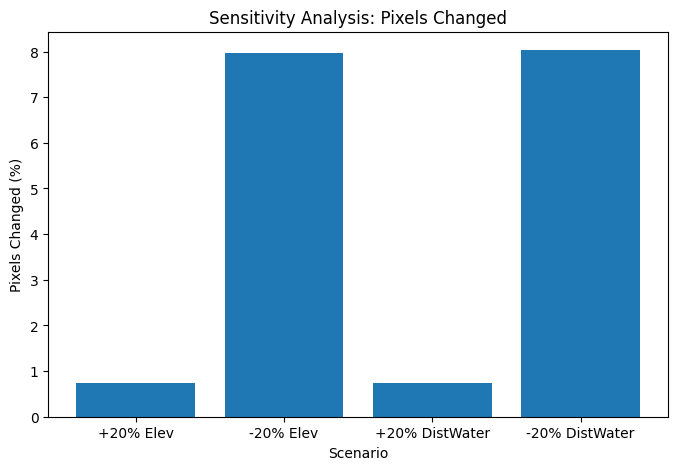

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# ข้อมูลจาก Sensitivity Analysis
scenarios = ["+20% Elev", "-20% Elev", "+20% DistWater", "-20% DistWater"]

pixels_changed = [0.746459, 7.960171, 0.730072, 8.032296]

x = np.arange(len(scenarios))


# Plot Pixels Changed (%)
plt.figure(figsize=(8,5))
plt.bar(x, pixels_changed)

plt.xticks(x, scenarios)
plt.ylabel("Pixels Changed (%)")
plt.xlabel("Scenario")
plt.title("Sensitivity Analysis: Pixels Changed")

plt.savefig(
    "Sensitivity_Pixels_Changed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Uncertainty Map (Robust vs Uncertain Areas)
# นับจำนวนครั้งที่ class เปลี่ยนจาก baseline
change_images = []

for name in scenarios:

    if name == "Baseline":
        continue

    change = base_class.neq(class_images[name])
    change_images.append(change)

# รวมจำนวนครั้งที่เปลี่ยน
uncertainty = ee.ImageCollection(change_images).sum().clip(roi)

# แสดงสถิติ
uncertainty_stats = uncertainty.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=500,
    bestEffort=True
).getInfo()

print("Average uncertainty:", uncertainty_stats)

# Map Visualization
Map3 = geemap.Map()

Map3.centerObject(roi, 9)

uncertainty_vis = {
    "min": 0,
    "max": 4,
    "palette": [
        "green",
        "yellow",
        "orange",
        "red"
    ]
}

Map3.addLayer(
    uncertainty,
    uncertainty_vis,
    "Model Uncertainty"
)

Map3.addLayer(
    classified,
    {"min":1,"max":3,
     "palette":["red","yellow","green"]},
    "Baseline Suitability"
)

Map3.addLayer(roi, {}, "Suphan Buri")
Map3

Average uncertainty: {'constant': 0.17468999465779306}


Map(center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position', 'transparent_…

In [28]:
# Validation กับข้อมูลจริง

import pandas as pd
import numpy as np

# -----------------------------------------------------------
# สร้าง Reference Points จากข้อมูล Proxy
# (ใช้ MODIS landcover + JRC water เป็น ground truth proxy)
# -----------------------------------------------------------

# สร้าง "expected" suitability ตาม land cover categories
# Cropland (12) → High (3), Grassland (10) → Moderate (2), อื่นๆ → Low (1)
reference = landcover.expression(
    "(b == 12) ? 3"
    ": (b == 14) ? 2"
    ": (b == 10) ? 2"
    ": 1",
    {"b": landcover}
).clip(roi).rename('reference')

# Mask areas permanently under water (ไม่นับเป็น validation point)
non_water = water.lt(50)
reference = reference.updateMask(non_water)
classified_masked = classified.updateMask(non_water)


# Random Sampling — Stratified (100 pts per class)
N_SAMPLES = 100  # ต่อ class

sample_points = classified_masked.addBands(reference).stratifiedSample(
    numPoints=N_SAMPLES,
    classBand='constant',   # band name ของ classified image
    region=roi,
    scale=500,
    seed=42,
    geometries=False
)

# ดึงค่าเป็น list
sample_data = sample_points.select(
    ['constant', 'reference']
).getInfo()

# แปลง features เป็น arrays
predicted = np.array([f['properties']['constant']
                       for f in sample_data['features']])
observed  = np.array([f['properties']['reference']
                       for f in sample_data['features']])

print(f"Total validation samples: {len(predicted)}")
print(f"Class distribution (predicted): {dict(zip(*np.unique(predicted, return_counts=True)))}")
print(f"Class distribution (observed):  {dict(zip(*np.unique(observed,  return_counts=True)))}")


# Confusion Matrix
classes = [1, 2, 3]
n = len(classes)
cm = np.zeros((n, n), dtype=int)

for p, o in zip(predicted, observed):
    if p in classes and o in classes:
        cm[classes.index(o), classes.index(p)] += 1

cm_df = pd.DataFrame(cm,
    index  =[f'Observed: {"Low" if c==1 else "Moderate" if c==2 else "" if c==3 else "High"}' for c in classes],
    columns=[f'Pred: {"Low" if c==1 else "Moderate" if c==2 else "High"}' for c in classes])
print("\n=== Confusion Matrix ===")
print(cm_df.to_string())


# Accuracy Metrics


total = cm.sum()

# Overall Accuracy
OA = np.diag(cm).sum() / total
print(f"\nOverall Accuracy (OA):  {OA:.4f}  ({OA*100:.2f}%)")

# Kappa Coefficient
row_sum = cm.sum(axis=1)
col_sum = cm.sum(axis=0)
p_e = (row_sum * col_sum).sum() / (total ** 2)
kappa = (OA - p_e) / (1 - p_e)
print(f"Kappa Coefficient (κ):  {kappa:.4f}")

# Per-class Precision, Recall, F1
print("\n=== Per-class Metrics ===")
class_names = ['Low', 'Moderate', 'High']
metrics_rows = []
for i, cls in enumerate(class_names):
    TP = cm[i, i]
    FP = col_sum[i] - TP
    FN = row_sum[i] - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    metrics_rows.append({
        'Class':     cls,
        'TP':        TP,
        'FP':        FP,
        'FN':        FN,
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'F1-Score':  round(f1, 4)
    })

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string(index=False))

# Macro-averaged F1
macro_f1 = metrics_df['F1-Score'].mean()
print(f"\nMacro-averaged F1: {macro_f1:.4f}")


# Visualize Validation Points บน Map

Map4 = geemap.Map()
Map4.centerObject(roi, 9)
Map4.addLayer(classified, {"min": 1, "max": 3,
    "palette": ["red", "yellow", "green"]}, "Classified (Baseline)")
Map4.addLayer(reference.randomVisualizer(), {}, "Reference (Ground Truth)")

# Error image (ที่ไหน predicted ≠ observed)
error_img = classified.neq(reference).selfMask()
Map4.addLayer(error_img, {"min": 1, "max": 1,
    "palette": ["purple"]}, "Misclassified pixels")
Map4.addLayer(roi, {}, "Suphan Buri Boundary")
Map4

Total validation samples: 237
Class distribution (predicted): {np.int64(1): np.int64(37), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}
Class distribution (observed):  {np.int64(1): np.int64(40), np.int64(2): np.int64(30), np.int64(3): np.int64(167)}

=== Confusion Matrix ===
                    Pred: Low  Pred: Moderate  Pred: High
Observed: Low              25              15           0
Observed: Moderate         11              19           0
Observed:                   1              66         100

Overall Accuracy (OA):  0.6076  (60.76%)
Kappa Coefficient (κ):  0.3701

=== Per-class Metrics ===
   Class  TP  FP  FN  Precision  Recall  F1-Score
     Low  25  12  15     0.6757  0.6250    0.6494
Moderate  19  81  11     0.1900  0.6333    0.2923
    High 100   0  67     1.0000  0.5988    0.7491

Macro-averaged F1: 0.5636


Map(center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position', 'transparent_…

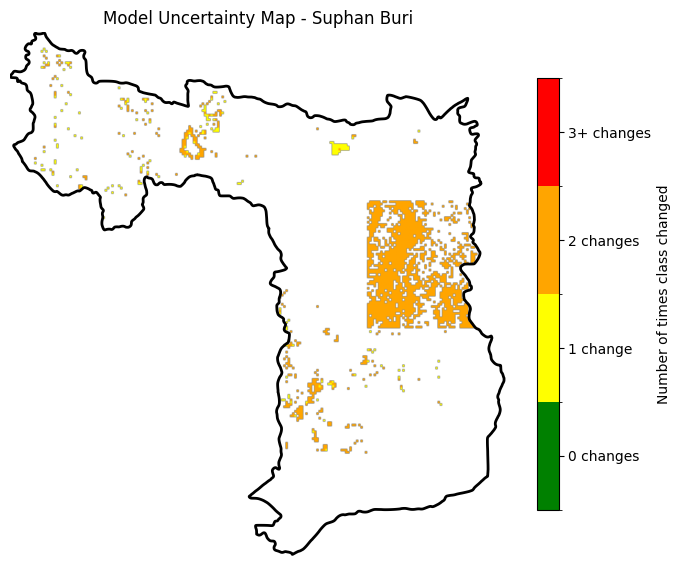

In [48]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import geemap # Import geemap to use ee_to_gdf
import ee # Import ee to create FeatureCollection

# อ่าน raster
src = rasterio.open("Model_Uncertainty.tif")
img = src.read(1)

# ซ่อนค่าพื้นที่นอกจังหวัด
img = np.where(img == 0, np.nan, img)

# Convert ee.Geometry roi to GeoDataFrame
gdf_roi = geemap.ee_to_gdf(ee.FeatureCollection([ee.Feature(roi)]))

plt.figure(figsize=(8,8))

# กำหนดสี uncertainty
colors = uncertainty_vis["palette"]
cmap = mcolors.ListedColormap(colors)
bounds = [0,1,2,3,4]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Get extent from rasterio source
extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

im = plt.imshow(img, cmap=cmap, norm=norm, extent=extent)

# Explicitly set plot limits to match the image extent for geopandas alignment
plt.xlim(extent[0], extent[1])
plt.ylim(extent[2], extent[3])

# วาดขอบเขตจังหวัดจาก GeoDataFrame
gdf_roi.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=2)

# Legend
cbar = plt.colorbar(im, shrink=0.7, ticks=[0.5,1.5,2.5,3.5])
cbar.ax.set_yticklabels(['0 changes','1 change','2 changes','3+ changes'])
cbar.set_label("Number of times class changed")

plt.title("Model Uncertainty Map - Suphan Buri")

plt.axis("off")

plt.savefig(
    "Model_Uncertainty_Map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()